In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import json
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

from config import BASE_PATH, ARTIFACT_DIR

print(f"BASE_PATH: {BASE_PATH}")
print(f"ARTIFACT_DIR: {ARTIFACT_DIR}")
print("Mounted and ready")

Mounted at /content/drive
Mounted and ready


In [56]:
# 2. Load data
s1 = pd.read_csv(f'{BASE_PATH}/dataset/train/train_source1.tsv', sep='\t')
s2 = pd.read_csv(f'{BASE_PATH}/dataset/train/train_source2.tsv', sep='\t')
s3 = pd.read_csv(f'{BASE_PATH}/dataset/train/train_source3.tsv', sep='\t')
gt = pd.read_csv(f'{BASE_PATH}/dataset/train/train_ground_truth.tsv', sep='\t')

# Clean column names
for df in (s1, s2, s3, gt):
    df.columns = [c.strip() for c in df.columns]

print("Loaded:")
print("S1:", s1.shape)
print("S2:", s2.shape)
print("S3:", s3.shape)
print("GT:", gt.shape)

Loaded:
S1: (2206821, 4)
S2: (5034616, 4)
S3: (5285603, 4)
GT: (2206821, 2)


In [57]:
# 3. Schema / column inspection
for name, df in {"S1": s1, "S2": s2, "S3": s3, "GT": gt}.items():
    print(f"\n{name} columns:")
    display(pd.DataFrame({
        "column": df.columns,
        "dtype": [str(df[c].dtype) for c in df.columns],
        "non_empty": [(df[c].astype(str).str.strip() != "").sum() for c in df.columns],
    }))


S1 columns:


,column,dtype,non_empty
0,entity_id,object,2206821
1,business_name,object,2206821
2,business_address,object,2206821
3,country,object,2206821



S2 columns:


,column,dtype,non_empty
0,entity_id,object,5034616
1,business_name,object,5034616
2,business_address,object,5034616
3,country,object,5034616



S3 columns:


,column,dtype,non_empty
0,entity_id,object,5285603
1,business_name,object,5285603
2,business_address,object,5285603
3,country,object,5285603



GT columns:


,column,dtype,non_empty
0,source1_entity_id,object,2206821
1,matched_entity_ids,object,2206821


In [59]:
# 4. Core integrity checks

def duplicate_id_report(df, id_col, label):
    if id_col not in df.columns:
        return
    dup = df[id_col].astype(str).duplicated().sum()
    print(f"{label}: {dup:,} duplicate IDs in {id_col}")


# All source tables use: entity_id
duplicate_id_report(s1, "entity_id", "S1")
duplicate_id_report(s2, "entity_id", "S2")
duplicate_id_report(s3, "entity_id", "S3")

# Ground truth uses: source1_entity_id
duplicate_id_report(gt, "source1_entity_id", "GT")


# Check that every GT S1 ID exists in S1
s1_ids = set(s1["entity_id"].astype(str))
gt_ids = set(gt["source1_entity_id"].astype(str))

print("GT S1 IDs missing from S1:", len(gt_ids - s1_ids))


# Basic source ID counts
s2_ids = set(s2["entity_id"].astype(str))
s3_ids = set(s3["entity_id"].astype(str))

print("S1 unique IDs:", len(s1_ids))
print("S2 unique IDs:", len(s2_ids))
print("S3 unique IDs:", len(s3_ids))

S1: 0 duplicate IDs in entity_id
S2: 0 duplicate IDs in entity_id
S3: 0 duplicate IDs in entity_id
GT: 0 duplicate IDs in source1_entity_id
GT S1 IDs missing from S1: 0
S1 unique IDs: 2206821
S2 unique IDs: 5034616
S3 unique IDs: 5285603


In [60]:
# 5. Missingness report

def missingness_table(df, label):
    out = pd.DataFrame({
        "source": label,
        "column": df.columns,
        "missing_or_empty": [
            df[c].isna().sum() + (df[c].astype(str).str.strip() == "").sum()
            for c in df.columns
        ],
    })
    out["rows"] = len(df)
    out["missing_pct"] = 100 * out["missing_or_empty"] / max(len(df), 1)
    return out

missingness = pd.concat([
    missingness_table(s1, "S1"),
    missingness_table(s2, "S2"),
    missingness_table(s3, "S3"),
    missingness_table(gt, "GT"),
], ignore_index=True)

display(missingness.sort_values(["source", "missing_pct"], ascending=[True, False]))

,source,column,missing_or_empty,rows,missing_pct
13,GT,matched_entity_ids,123247,2206821,5.584821
12,GT,source1_entity_id,0,2206821,0.000000
0,S1,entity_id,0,2206821,0.000000
1,S1,business_name,0,2206821,0.000000
2,S1,business_address,0,2206821,0.000000
3,S1,country,0,2206821,0.000000
6,S2,business_address,168967,5034616,3.356105
5,S2,business_name,2,5034616,0.000040
4,S2,entity_id,0,5034616,0.000000
7,S2,country,0,5034616,0.000000


In [61]:
# Fast dataset-level diagnostics
# These are O(number of rows) simple operations only; no pairwise duplicate work.

summary = pd.DataFrame({
    "source": ["S1", "S2", "S3", "GT"],
    "rows": [len(s1), len(s2), len(s3), len(gt)],
})
display(summary)

# Show a tiny sample so we understand the actual schema/content.
for label, df in {"S1": s1, "S2": s2, "S3": s3, "GT": gt}.items():
    print(f"\n{label} sample:")
    display(df.head(3))

,source,rows
0,S1,2206821
1,S2,5034616
2,S3,5285603
3,GT,2206821



S1 sample:


,entity_id,business_name,business_address,country
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US



S2 sample:


,entity_id,business_name,business_address,country
0,S2-166376419,राम मार्केटिंग प्राइवेट लिमिटेड,"KH NO. -570/13, NEW DELHI, WEST DELHI, Delhi",India
1,S2-764573417,-- Holloway Peak Inc Seafood,"105 ELM ST, MORGANTON, NC",US
2,S2-639257739,आदित्य प्रॉपर्टीज एलएलपी,"G-3/571, GULMOHAR COLONY, BHOPAL, Madhya Pradesh",India



S3 sample:


,entity_id,business_name,business_address,country
0,S3-202863386,wilfordhancock.com,"Mack Rd, Haltom City, Texas",US
1,S3-859268022,International South Consultants Private Ltd,NaN,India
2,S3-22467283,LLC Moncada Léarning Center,"5780 Fawn Ct, Fort Worth, Texas",US



GT sample:


,source1_entity_id,matched_entity_ids
0,S1-965667,"S2-681193310,S2-743505751,S3-775321672,S3-1129..."
1,S1-55344266,"S2-249013014,S2-197070651,S3-478195123,S3-3843..."
2,S1-343815751,"S2-790675320,S2-479876582,S3-878454467"


In [62]:
# Fast text diagnostics — only for columns that actually exist.
def fast_text_stats(df, label):
    rows = []
    candidate_cols = [
        c for c in df.columns
        if c.lower() in {"business_name", "name", "address", "business_address"}
    ]
    for c in candidate_cols:
        x = df[c].astype(str)
        rows.append({
            "source": label,
            "column": c,
            "empty_pct": 100 * (x.str.strip() == "").mean(),
            "median_len": x.str.len().median(),
            "p95_len": x.str.len().quantile(.95),
        })
    return rows

fast_stats = pd.DataFrame(
    fast_text_stats(s1, "S1") +
    fast_text_stats(s2, "S2") +
    fast_text_stats(s3, "S3")
)
display(fast_stats)

,source,column,empty_pct,median_len,p95_len
0,S1,business_name,0.0,24.0,37.0
1,S1,business_address,0.0,41.0,103.0
2,S2,business_name,0.0,25.0,40.0
3,S2,business_address,0.0,37.0,96.0
4,S3,business_name,0.0,25.0,42.0
5,S3,business_address,0.0,42.0,91.0


In [63]:
# Ground-truth parsing and match-count analysis

def parse_match_ids(value):
    if value is None:
        return set()
    value = str(value).strip()
    if not value:
        return set()
    return {x.strip() for x in value.split(",") if x.strip()}

gt_work = gt.copy()
gt_work["match_set"] = gt_work["matched_entity_ids"].map(parse_match_ids)
gt_work["match_count"] = gt_work["match_set"].map(len)
gt_work["has_match"] = (gt_work["match_count"] > 0).astype(int)

print("Match-count distribution:")
display(
    gt_work["match_count"]
    .value_counts()
    .sort_index()
    .rename("S1_entities")
    .to_frame()
)

print(f"Validation-relevant no-match rate: {(gt_work['match_count'] == 0).mean():.2%}")

Match-count distribution:


,S1_entities
match_count,
1,242404
2,375212
3,530841
4,484115
5,321957
6,164868
7,63968
8,18680
9,4205


Validation-relevant no-match rate: 0.00%


In [65]:
# Match source breakdown

s2_ids = set(s2["entity_id"].astype(str))
s3_ids = set(s3["entity_id"].astype(str))


def match_bucket(match_set):
    in_s2 = bool(match_set & s2_ids)
    in_s3 = bool(match_set & s3_ids)

    if not match_set:
        return "none"
    if in_s2 and in_s3:
        return "both"
    if in_s2:
        return "S2 only"
    if in_s3:
        return "S3 only"

    return "invalid / unknown ID"


gt_work["match_bucket"] = gt_work["match_set"].map(match_bucket)

bucket_counts = (
    gt_work["match_bucket"]
    .value_counts()
    .rename_axis("bucket")
    .to_frame("S1_entities")
)

bucket_counts["pct"] = (
    100 * bucket_counts["S1_entities"] / len(gt_work)
)

display(bucket_counts)

,S1_entities,pct
bucket,,
both,1776047,80.479885
S3 only,164498,7.454071
S2 only,143029,6.481223
invalid / unknown ID,123247,5.584821


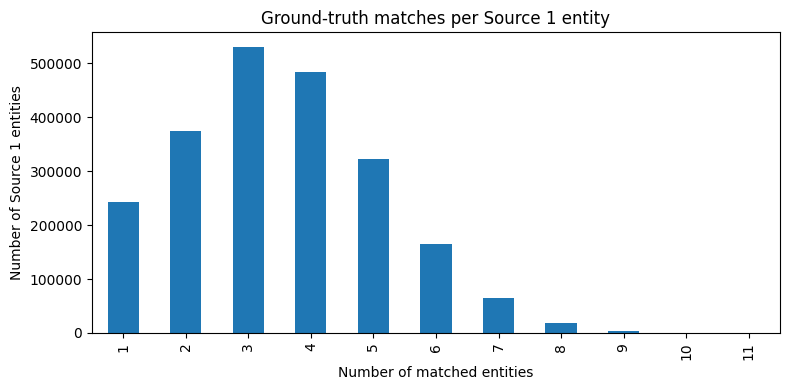

In [66]:
# One useful plot: match-count distribution
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
gt_work["match_count"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Ground-truth matches per Source 1 entity")
ax.set_xlabel("Number of matched entities")
ax.set_ylabel("Number of Source 1 entities")
plt.tight_layout()
plt.show()

In [67]:
# 12. Create and freeze an S1-level 80/20 validation split

if gt_work["source1_entity_id"].duplicated().any():
    raise ValueError("Ground truth is expected to have one row per S1 entity for this validation design.")

s1_ids_all = gt_work["source1_entity_id"].astype(str).values
labels = gt_work["has_match"].values

stratify_labels = labels if len(np.unique(labels)) == 2 else None

train_s1_ids, val_s1_ids = train_test_split(
    s1_ids_all,
    test_size=0.20,
    random_state=42,
    stratify=stratify_labels,
)

train_s1_ids = sorted(map(str, train_s1_ids))
val_s1_ids = sorted(map(str, val_s1_ids))

gt_train_80 = gt_work[gt_work["source1_entity_id"].isin(train_s1_ids)].drop(columns=["match_set"])
gt_val_20 = gt_work[gt_work["source1_entity_id"].isin(val_s1_ids)].drop(columns=["match_set"])

print("Train S1 entities:", len(gt_train_80))
print("Validation S1 entities:", len(gt_val_20))
print("Full S2 reference pool:", len(s2))
print("Full S3 reference pool:", len(s3))

print("\nValidation match-rate:")
print(gt_val_20["has_match"].mean())

Train S1 entities: 1765456
Validation S1 entities: 441365
Full S2 reference pool: 5034616
Full S3 reference pool: 5285603

Validation match-rate:
1.0


In [68]:
# 13. Export frozen validation artifacts

ARTIFACT_DIR = BASE_PATH / "code" / "src" / "validation_artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

gt_train_80.to_csv(ARTIFACT_DIR / "gt_train_80.tsv", sep="\t", index=False)
gt_val_20.to_csv(ARTIFACT_DIR / "gt_val_20.tsv", sep="\t", index=False)

with open(ARTIFACT_DIR / "val_s1_ids.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(val_s1_ids))

val_gt_dict = {
    str(row["source1_entity_id"]): sorted(parse_match_ids(row["matched_entity_ids"]))
    for _, row in gt_val_20.iterrows()
}

with open(ARTIFACT_DIR / "val_gt_dict.json", "w", encoding="utf-8") as f:
    json.dump(val_gt_dict, f, indent=2)

print("Saved validation artifacts to:", ARTIFACT_DIR)

Saved validation artifacts to: /content/drive/MyDrive/amazon_ml/code/src/validation_artifacts


In [69]:
# 14. F0.5 evaluator

def compute_f05_single(predicted, true):
    predicted = set(predicted)
    true = set(true)

    tp = len(predicted & true)
    fp = len(predicted - true)
    fn = len(true - predicted)

    # Explicit no-match handling.
    if len(true) == 0:
        return 1.0 if len(predicted) == 0 else 0.0

    precision = tp / len(predicted) if predicted else 0.0
    recall = tp / len(true) if true else 0.0

    denominator = 0.25 * precision + recall
    if denominator == 0:
        return 0.0

    return (1.25 * precision * recall) / denominator


def evaluate_f05_macro(pred_dict, true_dict):
    scores = []
    rows = []

    for s1_id, true_set in true_dict.items():
        pred_set = pred_dict.get(s1_id, set())
        score = compute_f05_single(pred_set, true_set)
        scores.append(score)

        tp = len(set(pred_set) & set(true_set))
        fp = len(set(pred_set) - set(true_set))
        fn = len(set(true_set) - set(pred_set))

        rows.append({
            "source1_entity_id": s1_id,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "precision": tp / (tp + fp) if (tp + fp) else (1.0 if not true_set and not pred_set else 0.0),
            "recall": tp / len(true_set) if true_set else (1.0 if not pred_set else 0.0),
            "f05": score,
        })

    per_entity = pd.DataFrame(rows)
    macro_f05 = float(np.mean(scores)) if scores else 0.0
    return macro_f05, per_entity


def aggregate_diagnostics(pred_dict, true_dict):
    tp = fp = fn = 0

    for s1_id, true_set in true_dict.items():
        pred_set = set(pred_dict.get(s1_id, set()))
        true_set = set(true_set)
        tp += len(pred_set & true_set)
        fp += len(pred_set - true_set)
        fn += len(true_set - pred_set)

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0

    return {
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "aggregate_precision": precision,
        "aggregate_recall": recall,
    }


print("F0.5 evaluator loaded.")

F0.5 evaluator loaded.


In [70]:
# 15. Build validation truth dictionary

val_gt_dict = {
    str(row["source1_entity_id"]): parse_match_ids(row["matched_entity_ids"])
    for _, row in gt_val_20.iterrows()
}

# Singleton/no-match baseline:
# predict NO MATCH for every validation S1.
singleton_pred = {s1_id: set() for s1_id in val_gt_dict}

baseline_f05, baseline_per_entity = evaluate_f05_macro(singleton_pred, val_gt_dict)
baseline_diag = aggregate_diagnostics(singleton_pred, val_gt_dict)

print(f"Singleton/no-match baseline — macro F0.5: {baseline_f05:.6f}")
print(baseline_diag)

Singleton/no-match baseline — macro F0.5: 0.000000
{'TP': 0, 'FP': 0, 'FN': 1553180, 'aggregate_precision': 0.0, 'aggregate_recall': 0.0}


In [71]:
# 16. Metric sanity tests

assert abs(compute_f05_single({"A"}, {"A"}) - 1.0) < 1e-12
assert abs(compute_f05_single(set(), set()) - 1.0) < 1e-12
assert abs(compute_f05_single({"A"}, set()) - 0.0) < 1e-12
assert abs(compute_f05_single(set(), {"A"}) - 0.0) < 1e-12

# True={A,B}, predicted={A}: precision=1, recall=0.5
expected = (1.25 * 1.0 * 0.5) / (0.25 * 1.0 + 0.5)
assert abs(compute_f05_single({"A"}, {"A", "B"}) - expected) < 1e-12

print("All evaluator sanity checks passed.")

All evaluator sanity checks passed.


In [72]:
# 17. Write a shared evaluator.py

evaluator_code = r'''
import numpy as np
import pandas as pd

def compute_f05_single(predicted, true):
    predicted = set(predicted)
    true = set(true)

    tp = len(predicted & true)
    fp = len(predicted - true)
    fn = len(true - predicted)

    if len(true) == 0:
        return 1.0 if len(predicted) == 0 else 0.0

    precision = tp / len(predicted) if predicted else 0.0
    recall = tp / len(true) if true else 0.0

    denominator = 0.25 * precision + recall
    if denominator == 0:
        return 0.0

    return (1.25 * precision * recall) / denominator


def evaluate_f05_macro(pred_dict, true_dict):
    scores = []
    rows = []

    for s1_id, true_set in true_dict.items():
        pred_set = pred_dict.get(s1_id, set())
        score = compute_f05_single(pred_set, true_set)
        scores.append(score)

        tp = len(set(pred_set) & set(true_set))
        fp = len(set(pred_set) - set(true_set))
        fn = len(set(true_set) - set(pred_set))

        rows.append({
            "source1_entity_id": s1_id,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "precision": tp / (tp + fp) if (tp + fp) else (1.0 if not true_set and not pred_set else 0.0),
            "recall": tp / len(true_set) if true_set else (1.0 if not pred_set else 0.0),
            "f05": score,
        })

    return (float(np.mean(scores)) if scores else 0.0), pd.DataFrame(rows)


def aggregate_diagnostics(pred_dict, true_dict):
    tp = fp = fn = 0

    for s1_id, true_set in true_dict.items():
        pred_set = set(pred_dict.get(s1_id, set()))
        true_set = set(true_set)
        tp += len(pred_set & true_set)
        fp += len(pred_set - true_set)
        fn += len(true_set - pred_set)

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0

    return {
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "aggregate_precision": precision,
        "aggregate_recall": recall,
    }
'''

(ARTIFACT_DIR / "evaluator.py").write_text(evaluator_code, encoding="utf-8")
print("Saved:", ARTIFACT_DIR / "evaluator.py")

Saved: /content/drive/MyDrive/amazon_ml/code/src/validation_artifacts/evaluator.py
